# Pipeline 1 - Dates Matching

The first pipeline will automate the following actions.<br>
INPUTS: 
* AOI
* PERIOD
* OUTPUT FOLDER (output will be organized by AOI)

ACTIONS:
1. Open the AOI
2. Create the S2 dataframe with cloud cover for the AOI and dates
3. Create the SWOT dataframe with the possible mosaics
4. Match SWOT and S2 dates, ordered by cloud cover
5. Create output structure in the AOI folder (/ref_masks, /OPERA, /dataframes)



## Imports

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from swot_toolkit.pipe1 import prepare_aoi_dataframes
from swot_toolkit.swot import auth_earthaccess

auth_earthaccess()

## Pipeline 1

In [1]:
REGION = "Northeast"
DATE_RANGE = ("2024-01-01", "2025-09-30")
OUTPUT_DIR = "/data/swot/output/"

Output directory created at: /data/swot/output/Northeast
Searching for Sentinel-2 scenes intersecting the AOI...
S2 tile not provided. Guessing the best tile...
Tile 24MWT has 0 null values.
Best tile is 24MWT.
Assessing clouds in Sentinel-2 scenes...


  0%|          | 0/287 [00:00<?, ?it/s]

Searching for OPERA satellite data intersecting the AOI...
Found 291 OPERA satellite overpasses intersecting the AOI.
Searching for SWOT Raster_100 data intersecting the AOI...
Creating SWOT mosaics...


  0%|          | 0/31 [00:00<?, ?it/s]

Saving dataframes to /data/swot/output/Northeast/dfs...


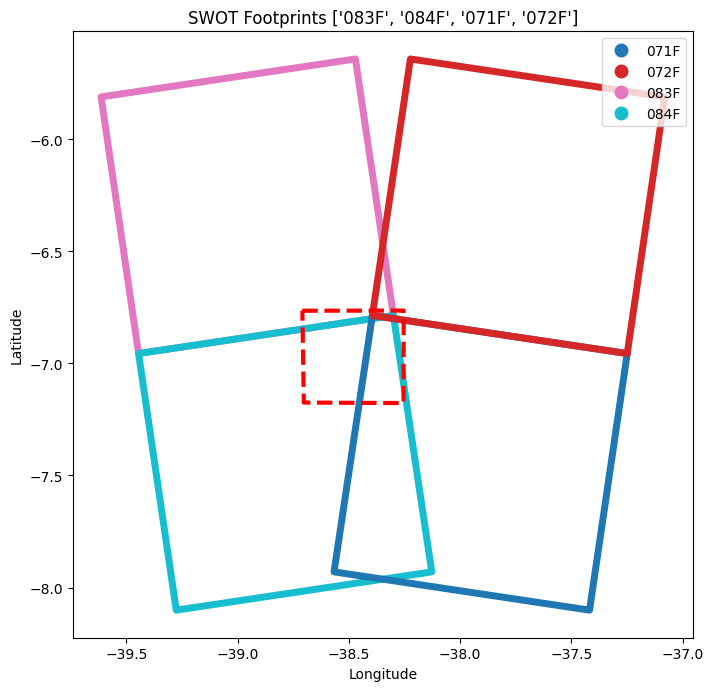

In [4]:
aoi_path = Path("/data/swot/AOIs/") / f"{REGION}.kml"
output_dir = prepare_aoi_dataframes(aoi_path, DATE_RANGE, OUTPUT_DIR)

## Analyze results

In [5]:
from pathlib import Path

import pandas as pd

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.pipe1 import generate_s2_figs_from_mosaic

In [6]:
output_dir = Path(OUTPUT_DIR) / REGION

In [7]:
# Open the matches between S2 and SWOT
matches = pd.read_parquet(output_dir / "dfs/swot_s2_matches.parquet")
matches.sort_values("valid_pxls", ascending=False).iloc[:10]

,date,datetime,tile,valid_pxls,OPERA
swot_mosaic_date,,,,,
2025-07-20,2025-07-16,2025-07-16 13:03:11.025,24MWT,0.995740,S2C
2024-05-29,2024-05-27,2024-05-27 13:02:49.024,24MWT,0.995400,S2B
2025-08-10,2025-08-07,2025-08-07 13:03:01.024,24MWT,0.995287,"S2B, S2A"
2025-08-31,2025-08-30,2025-08-30 13:02:49.024,24MWT,0.995172,S2B
2025-04-27,2025-04-27,2025-04-27 13:03:11.025,24MWT,0.995163,S2C
2024-07-09,2024-07-11,2024-07-11 13:02:51.024,24MWT,0.994336,S2A
2024-07-30,2024-07-31,2024-07-31 13:02:51.024,24MWT,0.994185,S2A
2024-12-02,2024-11-28,2024-11-28 13:02:41.024,24MWT,0.993803,S2A
2025-06-08,2025-06-08,2025-06-08 13:03:01.024,24MWT,0.993761,"S2B, S2A"


### Choose a mosaic date to check the S2 items (figs generated in output dir)

In [8]:
MOSAIC_DATE = "2025-07-20"

aoi = read_kml_geometry(aoi_path)[0]
s2_matches = generate_s2_figs_from_mosaic(
    MOSAIC_DATE,
    matches,
    aoi,
    output_dir,
)

s2_matches

Saving figure S2B_MSIL2A_20250721T130249_R095_T24MWT_20250721T145133_thumb.png...
Saving figure S2A_MSIL2A_20250718T130301_R095_T24MWT_20250718T173513_thumb.png...
Saving figure S2B_MSIL2A_20250718T125309_R052_T24MWT_20250718T162520_thumb.png...
Saving figure S2C_MSIL2A_20250716T130311_R095_T24MWT_20250716T173813_thumb.png...
Saving figure S2A_MSIL2A_20250715T125331_R052_T24MWT_20250715T185112_thumb.png...


,date,datetime,tile,valid_pxls,OPERA
swot_mosaic_date,,,,,
2025-07-20,2025-07-15,2025-07-15 12:53:31.024,24MWT,0.319384,S2A
2025-07-20,2025-07-16,2025-07-16 13:03:11.025,24MWT,0.995740,S2C
2025-07-20,2025-07-18,2025-07-18 13:03:01.024,24MWT,0.981792,"S2B, S2A"
2025-07-20,2025-07-21,2025-07-21 13:02:49.024,24MWT,0.984244,S2B


<Figure size 1000x1000 with 0 Axes>

### Selection of Ref S2 img

In [11]:
s2_id = "S2C_MSIL2A_20250716T130311_R095_T24MWT_20250716T173813"


In [12]:
from swot_toolkit.pipe1 import create_date_subfolder

create_date_subfolder(output_dir, MOSAIC_DATE, s2_id)

PosixPath('/data/swot/output/Northeast/2025-07-20')